In [1]:
%load_ext autoreload 
%autoreload 2
from xtr_estimator.logger import setup_logger

logger = setup_logger()

{'diffmap_type': 'tv', 'dark_mean_correction': True, 'simple_dark_correction': True, 'calculate_diffmap_before_f000': False, 'preprocessing': False}


2026-04-09 15:08:44,299: xtr_estimator.logger: INFO: Imposing high_resolution_limit: 2.3 (processing.py:94)
2026-04-09 15:08:44,829: xtr_estimator.logger: INFO: No recent preprocessed diffmap found at tmp/myo_0.1ps/myo_0.1ps/diffmap_23.0_tv_110.mtz, calculating diffmap... (processing.py:254)
2026-04-09 15:08:44,829: xtr_estimator.logger: INFO: this is calculate_again True (processing.py:150)
2026-04-09 15:08:44,831: xtr_estimator.logger: WARNING: Loaded meta from file: (processing.py:164)
2026-04-09 15:08:44,831: xtr_estimator.logger: INFO: loading: 0.01, tv_weight: 0.04801479540650362, only_kweighted: False (processing.py:172)


2026-04-09 15:08:44 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-04-09 15:08:44 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-04-09 15:08:44 [info     ] Computing difference map.     
2026-04-09 15:08:44 [info     ]   using fixed                  kparameter=0.01
2026-04-09 15:08:44 [info     ] TV denoising with fixed weight weight=0.04801479540650362
2026-04-09 15:08:45 [info     ] Map TV-denoised with fixed weight final_negentropy=4.18e-01 initial_negentropy=1.92e-03 weight=0.04801479540650362


2026-04-09 15:08:45,098: xtr_estimator.logger: INFO: diffmap has uncertainties: True (processing.py:214)
2026-04-09 15:08:45,103: xtr_estimator.logger: INFO: Saved diffmap to tmp/myo_0.1ps/myo_0.1ps/diffmap_23.0_tv_110.mtz (processing.py:279)
2026-04-09 15:08:45,113: xtr_estimator.logger: INFO: ignore_mask voxel count: 0.2712890625 (processing.py:304)
2026-04-09 15:08:45,114: xtr_estimator.logger: INFO: Shift value 0.32269 corresponds to zero frequency 20175.607 (processing.py:318)
2026-04-09 15:08:45,125: xtr_estimator.logger: WARNING: Diffmap Mean: -0.000000, Std: 0.019824 (4079405080.py:17)
2026-04-09 15:08:45,130: xtr_estimator.logger: WARNING: Used threshold for posmask: 0.064, found 9 blobs (masking.py:144)
2026-04-09 15:08:45,131: xtr_estimator.logger: INFO: Using blobs with more than 0.07370142836165655(0.03 A^3) voxels (masking.py:161)
2026-04-09 15:08:45,131: xtr_estimator.logger: INFO: Maximum Blob sizes found: 93 (masking.py:162)
2026-04-09 15:08:45,135: xtr_estimator.logge

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Difference Map $-\\Delta \\rho$ (standard deviations)', ylabel='Extrapolation factor $ \\chi^{-1} = -\\Delta\\rho/\\rho_{0}$'>,
 (np.float64(0.6209329458383414), np.float64(0.17231534503230822)))

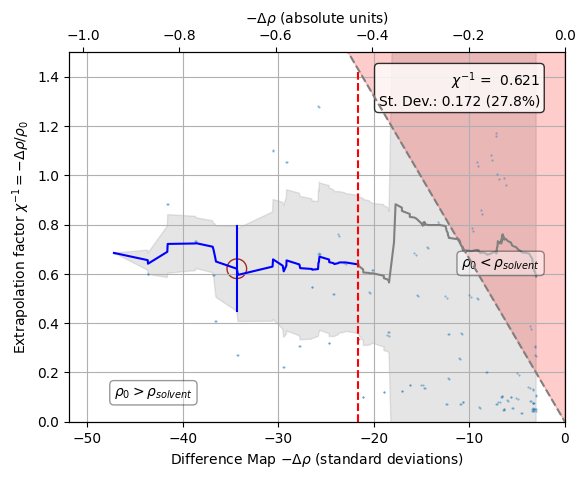

In [2]:
import copy 

from xtr_estimator.configuration import minimal_masking_config
from xtr_estimator.processing import get_maps, prepare_maps
from xtr_estimator.masking import make_inclusion_mask
from xtr_estimator.estimation import plot_extrapolation_estimate
from dataset_configs import apply_config_myoglobin_general

config = apply_config_myoglobin_general("0.1ps")
print(config["map_processing"])
config["map_processing"]["calculate_diffmap_before_f000"] = True

unscaled_dark, unscaled_triggered = get_maps(config)
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
)
config_nse=copy.deepcopy(config)

config_nse["masking"] = minimal_masking_config()
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)


config["plot"]["set_ylim"] = ((0, 1.5))
plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)

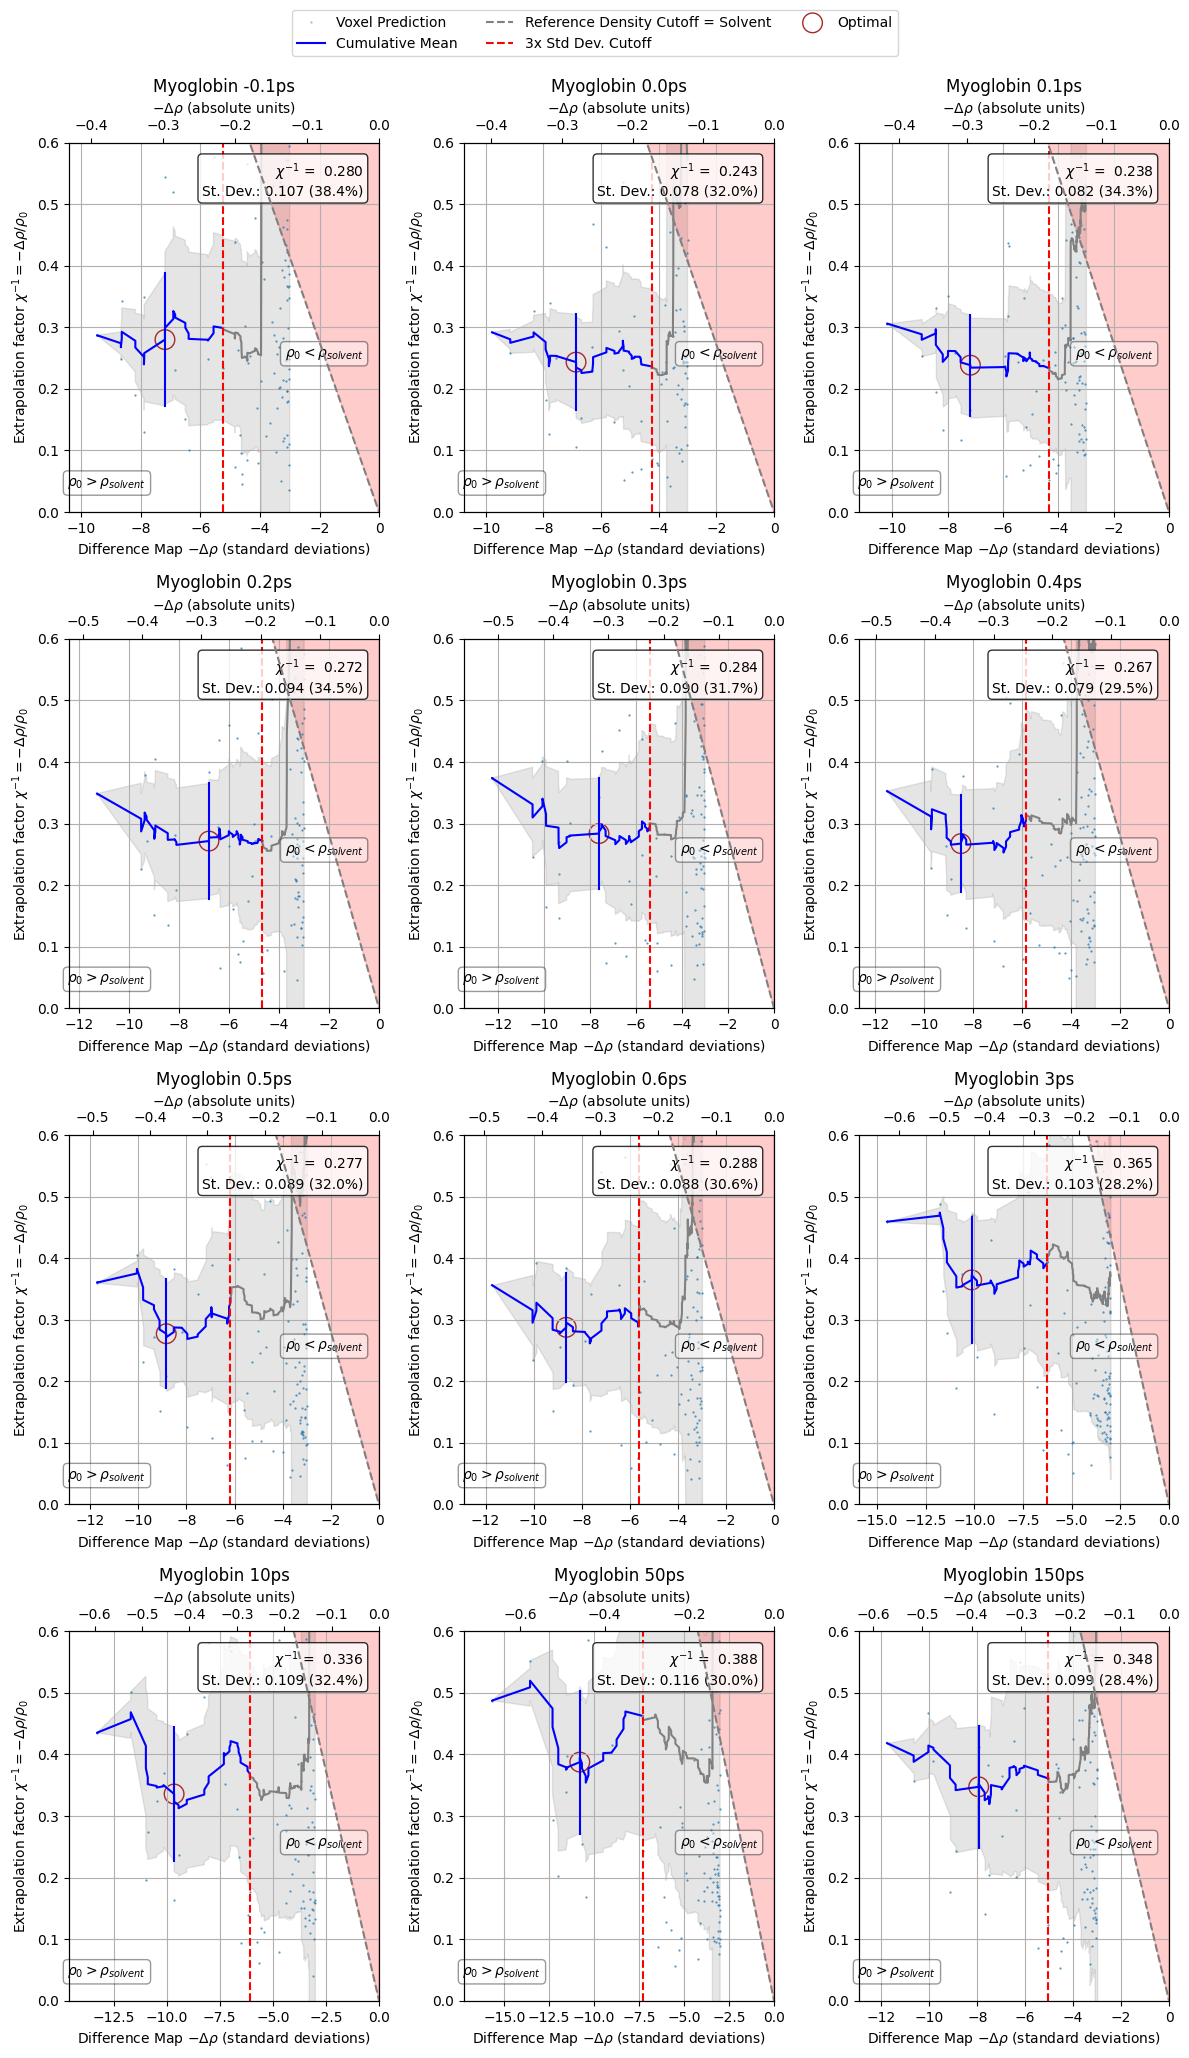

In [3]:
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from logger import setup_logger
import logging 
import matplotlib.pyplot as plt
logger = setup_logger(log_level=logging.ERROR)

# 1. Create the main figure
fig,axs = plt.subplots(4,3, figsize=(12, 20), tight_layout=True)

for i, ax in enumerate(axs.flatten()):
    # if not i: continue

    config = apply_config_myoglobin_general(i)
    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0

    unscaled_dark, unscaled_triggered = get_maps(config)
    config["map_processing"]["diffmap_type"]="vanilla"
    config["map_processing"]["calculate_diffmap_before_f000"] = True
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)


    config_nse["masking"] = minimal_masking_config()
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)
    if config["map_processing"]["diffmap_type"]=="tv":
        config["plot"]["set_ylim"] = ((0, 1.5))
    else:
        config["plot"]["set_ylim"] = ((0, 0.6))

    plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()


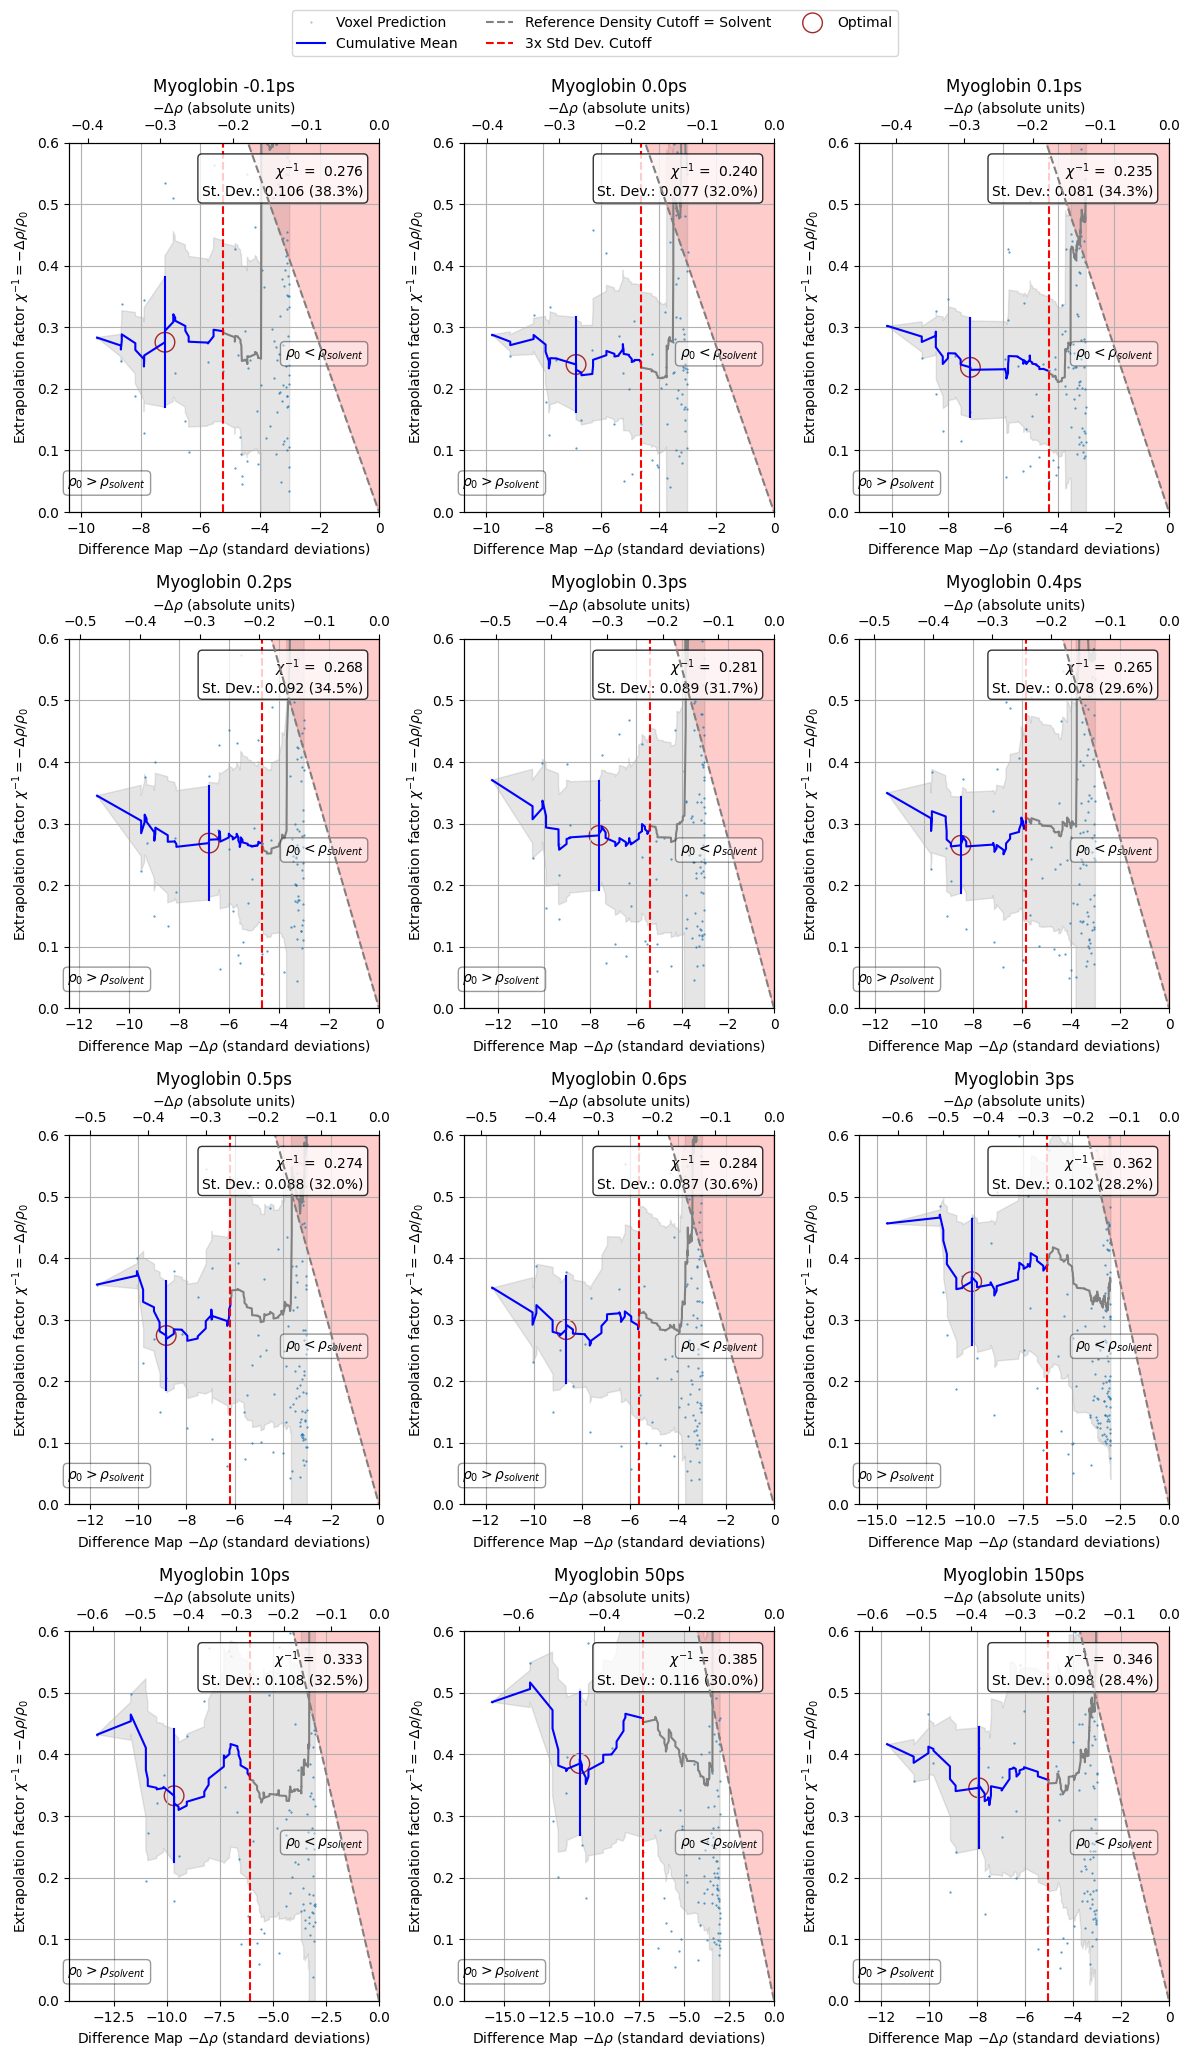

In [4]:
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from logger import setup_logger
import logging 
import matplotlib.pyplot as plt
logger = setup_logger(log_level=logging.ERROR)

# 1. Create the main figure
fig,axs = plt.subplots(4,3, figsize=(12, 20), tight_layout=True)

for i, ax in enumerate(axs.flatten()):
    # if not i: continue

    config = apply_config_myoglobin_general(i)
    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0

    unscaled_dark, unscaled_triggered = get_maps(config)
    config["map_processing"]["diffmap_type"]="vanilla"
    config["map_processing"]["calculate_diffmap_before_f000"] = False
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)


    config_nse["masking"] = minimal_masking_config()
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)
    if config["map_processing"]["diffmap_type"]=="tv":
        config["plot"]["set_ylim"] = ((0, 1.5))
    else:
        config["plot"]["set_ylim"] = ((0, 0.6))

    plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config, ax)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()

